In [18]:
import math
import numpy as np
from SDP_utils.combinatorics import occupation_index, nu_set_iterator, multinomial, nu_iterator, dim_sym_kd
from SDP_utils.isotopic_proj import isotypic_projector
from tqdm.notebook import tqdm
import numpy as np
import picos
from SDP_utils.E_t import E_t_lowerk2, E_t_upperk2r2
from toqito.state_props import is_separable

SDP_TOL = 10**(-7)

ImportError: cannot import name 'E_t_upperk2r2' from 'SDP_utils.E_t' (/home/anton/internship/SDP_utils/E_t.py)

In [ ]:


sb = ""
for k in range(2, 6):
    sb += f"        ${k}$ & "
    for i in range(2,6):
        val = (i*i)**k
        if val < 300:
            sb += f"${val}$ {"&" if i<5 else ""} "
        else:
            sb += f"${val:.0e}$ {"&" if i<5 else ""} "
    sb += "\\\\\n"

sb2 = ""
for k in range(2, 6):
    sb2 += f"       ${k}$ & "
    for i in range(2,6):
        val = dim_sym_kd(k, i*i)
        if val < 300:
            sb2 += f"${val}$ {"&" if i<5 else ""} "
        else:
            sb2 += f"${val:.0e}$ {"&" if i<5 else ""} "
    sb2 += "\\\\\n"\
    

tbl = f"""\\begin{{table}}[]
    \\begin{{tabular}}{{c|c c c c}}
        $k \\setminus d$ & $2\\times2$ & $3\\times3$ & $4\\times4$ & $5\\times5$ \\\\
{sb}
    \\end{{tabular}}
    \\begin{{tabular}}{{c|c c c c}}
        $k \\setminus d$ & $2\\times2$ & $3\\times3$ & $4\\times4$ & $5\\times5$ \\\\
{sb2}
    \\end{{tabular}}
    \\caption{{Left non-reduced, right reduced. I would maybe highlight somehow (e.g. in green vs red) those that can be computed and those that cannot.}}
    \\label{{tab:placeholder}}
\\end{{table}}"""

print(tbl)

\begin{table}[]
    \begin{tabular}{c|c c c c}
        $k \setminus d$ & $2\times2$ & $3\times3$ & $4\times4$ & $5\times5$ \\
        $2$ & $16$ & $81$ & $256$ & $6e+02$  \\
        $3$ & $64$ & $7e+02$ & $4e+03$ & $2e+04$  \\
        $4$ & $256$ & $7e+03$ & $7e+04$ & $4e+05$  \\
        $5$ & $1e+03$ & $6e+04$ & $1e+06$ & $1e+07$  \\

    \end{tabular}
    \begin{tabular}{c|c c c c}
        $k \setminus d$ & $2\times2$ & $3\times3$ & $4\times4$ & $5\times5$ \\
       $2$ & $10$ & $45$ & $136$ & $3e+02$  \\
       $3$ & $20$ & $165$ & $8e+02$ & $3e+03$  \\
       $4$ & $35$ & $5e+02$ & $4e+03$ & $2e+04$  \\
       $5$ & $56$ & $1e+03$ & $2e+04$ & $1e+05$  \\

    \end{tabular}
    \caption{Left non-reduced, right reduced. I would maybe highlight somehow (e.g. in green vs red) those that can be computed and those that cannot.}
    \label{tab:placeholder}
\end{table}


In [ ]:
from SDP_utils.sdp import SDP, SDP_max

## Caching helper: `get_SDP_bounds`

Generic helper that sweeps a 1-parameter family of states through the SDP, caches the
results to disk (keyed by `label`, `m`, `k` and the requested range), and re-loads them
instead of recomputing if the exact same sweep has already been run.


In [ ]:
import os
import json
import numpy as np
from tqdm.notebook import tqdm
from SDP_utils.sdp import SDP
from SDP_utils.E_t import E_t_lowerk2
from toqito.state_props import is_separable

SDP_TOL = 10**(-7)
RESULTS_DIR = "sdp_results"


def antiSymProjector(k):
    return [1] * k


def _cache_path(label, m, k, param_range):
    start, end, step = param_range
    os.makedirs(RESULTS_DIR, exist_ok=True)
    safe_label = "".join(c if c.isalnum() or c in "-_" else "_" for c in label)
    fname = f"{safe_label}_m{m}_k{k}_{start}_{end}_{step}.json"
    return os.path.join(RESULTS_DIR, fname)


def _package(p_vals, obj_vals, separable, Etl_vals, m, label, param_range, k):
    return {
        "p_vals": np.array(p_vals),
        "obj_vals": np.array(obj_vals, dtype=float),
        "separable": np.array(separable, dtype=bool),
        "Etl_vals": np.array(Etl_vals, dtype=float),
        "m": m,
        "label": label,
        "range": tuple(param_range),
        "k": k,
    }


def get_SDP_bounds(m, generator, label, param_range, k=2, projector=None,
                    force_recompute=False, verbose=True):
    """
    Sweep a 1-parameter family of states through the SDP and cache the results,
    writing the result file to disk after *every* point (not just at the end),
    so an interrupted / crashed run doesn't lose already-computed points.

    Parameters
    ----------
    m : int
        Local dimension; states live in C^m x C^m.
    generator : callable
        Takes a single float `p` and returns the corresponding density matrix
        (numpy array). Examples:
            generator = C3C3_horodecki
            generator = convex_combination_generator(cross_hatch_state(), max_mixed(m**2))
    label : str
        Human readable name used to build the cache filename, e.g. "C3C3_horodecki".
    param_range : tuple
        (start, end, step) fed to np.arange to build the parameter grid.
    k : int, default 2
        Symmetry degree. Used to build the default antisymmetric projector [1]*k
        (and passed to E_t_lowerk2) unless `projector` is given explicitly.
    projector : list, optional
        Explicit projector spec forwarded to SDP(). Defaults to antiSymProjector(k).
    force_recompute : bool, default False
        If True, ignore any cached file on disk and recompute everything from scratch.
    verbose : bool, default True
        Print progress / cache hit messages and show a progress bar.

    Returns
    -------
    dict with keys:
        p_vals     : np.ndarray of parameter values
        obj_vals   : np.ndarray of SDP objective values
        separable  : np.ndarray[bool] (from toqito.is_separable)
        Etl_vals   : np.ndarray of lower bound on E_t (0 where separable or below tol)
        m, label, range, k : metadata echoed back
    """
    filename = _cache_path(label, m, k, param_range)
    start, end, step = param_range
    grid = np.arange(start, end, step)

    p_vals, obj_vals, separable, Etl_vals = [], [], [], []

    if os.path.exists(filename) and not force_recompute:
        with open(filename, "r") as f:
            data = json.load(f)
        p_vals = data.get("p_vals", [])
        obj_vals = data.get("obj_vals", [])
        separable = data.get("separable", [])
        Etl_vals = data.get("Etl_vals", [])

        if len(p_vals) >= len(grid):
            if verbose:
                print(f"[get_SDP_bounds] loading complete cached results from {filename}")
            return _package(p_vals, obj_vals, separable, Etl_vals, m, label, param_range, k)
        elif len(p_vals) > 0 and verbose:
            print(f"[get_SDP_bounds] resuming: {len(p_vals)}/{len(grid)} points already "
                  f"cached in {filename}, continuing from there")

    n_done = len(p_vals)
    proj = projector if projector is not None else antiSymProjector(k)

    def _save():
        result = {
            "p_vals": p_vals,
            "obj_vals": obj_vals,
            "separable": separable,
            "Etl_vals": Etl_vals,
            "m": m,
            "label": label,
            "range": [start, end, step],
            "k": k,
        }
        with open(filename, "w") as f:
            json.dump(result, f, indent=2)

    remaining = grid[n_done:]
    if verbose:
        iterator = tqdm(remaining, desc=label, initial=n_done, total=len(grid))
    else:
        iterator = remaining

    for p in iterator:
        p = float(p)
        print(p)
        state = generator(p)
        obj, omega_sym = SDP(proj, state, m, m)
        if(obj < SDP_TOL): 
            sep, _ = is_separable(state)
            # sep = False
        else:
            sep = False
        print(f"obj {obj < SDP_TOL}")

        if not sep:
            Etl = float(E_t_lowerk2(k, 1, obj))
        else:
            Etl = 0.0

        p_vals.append(p)
        obj_vals.append(float(obj))
        separable.append(bool(sep))
        Etl_vals.append(Etl)

        # persist after every single point, so a crash mid-sweep loses at most
        # the point currently in flight
        _save()

    if verbose:
        print(f"[get_SDP_bounds] saved {len(p_vals)} points to {filename}")

    return _package(p_vals, obj_vals, separable, Etl_vals, m, label, param_range, k)


def convex_combination_generator(state1, state2):
    """
    Build a single-parameter generator g(p) = p * state1 + (1 - p) * state2,
    suitable for get_SDP_bounds. Use this to turn e.g. cross_hatch_state() /
    max_mixed(m**2) into the `generator` argument.

    NB: check this matches the convention used by your own
    CmCn_entangled.convex_combination.convex_combination iterator
    (some implementations use p*state2 + (1-p)*state1 instead) and swap the
    two terms below if needed.
    """
    def gen(p):
        return p * state1 + (1 - p) * state2
    return gen


import matplotlib.pyplot as plt


def plot_Etl_bounds(results, title, xlabel="p"):
    """
    Plot the Etl_vals stored in a get_SDP_bounds() result dict, on a log scale,
    color-coding separable vs entangled points (mirrors the plotting cells
    used throughout this notebook).
    """
    p_vals = results["p_vals"]
    Etl_vals = results["Etl_vals"]
    separable = results["separable"]

    eps = 1e-6
    plot_vals = np.where(Etl_vals <= 0, eps, Etl_vals)

    plt.figure(figsize=(7, 5))
    plt.plot(p_vals, plot_vals, color="gray", linestyle="-", alpha=0.6, zorder=1)
    plt.scatter(p_vals[~separable], plot_vals[~separable],
                color="crimson", marker="o", s=50, label="entangled", zorder=2)
    plt.scatter(p_vals[separable], plot_vals[separable],
                color="royalblue", marker="x", s=60, label="separable", zorder=2)

    plt.yscale("log")
    plt.xlabel(xlabel)
    plt.ylabel("$E_{t}^{lower}$ (log scale)")
    plt.title(title)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend()
    plt.show()


### Example usage

```python
from C3C3_PPT_entangled import C3C3_horodecki, cross_hatch_state
from toqito.states import max_mixed

# Horodecki family: generator already takes a single scalar parameter
horodecki_res = get_SDP_bounds(
    m=3,
    generator=C3C3_horodecki,
    label="C3C3_horodecki",
    param_range=(0.01, 1.0, 0.02),
)

# Cross-hatch convex-combined with the maximally mixed state: build a
# single-parameter generator first
crosshatch_gen = convex_combination_generator(cross_hatch_state(), max_mixed(9))
crosshatch_res = get_SDP_bounds(
    m=3,
    generator=crosshatch_gen,
    label="cross_hatch_maxmixed",
    param_range=(0.0, 1.0, 0.05),
)
```

Re-running either cell with the same `label`, `m`, `k` and `param_range` will just reload
the JSON file from `sdp_results/` instead of solving the SDP again. Pass
`force_recompute=True` to force a fresh run, e.g. after fixing a bug in `generator`.


# Random entangled mixed state in $\mathbb{C}^2 \otimes \mathbb{C}^2$

In [ ]:
def antiSymProjector(k):
    return [1] * k

In [ ]:
# from C2C2_entangled.C2C2_rd_entangled import C2C2_random_mixed_entangled_state
# from state_logging import log_failed_state

# m = 2
# nb_identified = 0
# count = 10000
# FAILURE_LOG = "C2C2_entangled/not_identified.jsonl"

# for _ in tqdm(range(count)):
#     state = C2C2_random_mixed_entangled_state()
#     obj, omega_sym = SDP(antiSymProjector(2), state, m, m)
#     if obj > SDP_TOL:
#         nb_identified += 1
#     else:
#         log_failed_state(FAILURE_LOG, state)

# print(f"Correctly identified {nb_identified/count * 100}% in C2xC2")

In [ ]:
from C2C2_entangled.C2C2_rd_entangled import C2C2_random_mixed_entangled_state_tiny_eigen_value
from state_logging import log_failed_state

m = 2
nb_identified = 0
count = 100

for _ in tqdm(range(count)):
    state = C2C2_random_mixed_entangled_state_tiny_eigen_value()
    obj, omega_sym = SDP(antiSymProjector(2), state, m, m)
    if obj > SDP_TOL:
        nb_identified += 1

print(f"Correctly identified {nb_identified/count * 100}% in C2xC2")

  0%|          | 0/100 [00:00<?, ?it/s]

/home/anton/internship/SDP_utils/sdp.py:23: DeprecationWarning: Option 'verbose' is deprecated, use 'verbosity'.
  P = picos.Problem(verbose=verbose)


Correctly identified 100.0% in C2xC2


In [ ]:
# from CmCm_entangled.isotropic_state import isotropic

# for m in range(2,5):

#     a = 1 / (m + 1) - 0.001
#     state = isotropic(m, a)
#     obj, omega_sym = SDP([1,1], state, m,m, verbose=True)
#     print(f"m={m}, a = {a}, {obj}, {obj > SDP_TOL}, expect false")

#     a = 1 / (m + 1) + 0.001
#     state = isotropic(m, a)
#     obj, omega_sym = SDP([1,1], state, m,m, verbose=True)
#     print(f"m={m}, a = {a}, {obj}, {obj > SDP_TOL} expect true")

# Entangled mixed state in $\mathbb{C}^3 \otimes \mathbb{C}^3$

In [ ]:
from C3C3_PPT_entangled import extremal_PPT_chessboard, C3C3_horodecki, UPB, cross_hatch_state
from CmCn_entangled.convex_combination import convex_combination
from toqito.states import max_mixed
m = 3

state = extremal_PPT_chessboard()
obj, omega_sym = SDP([1,1], state, m,m)
print(f"{obj}, {obj > SDP_TOL} expect true")

0.07342465936426841, True expect true


## Horodecki

[get_SDP_bounds] loading complete cached results from sdp_results/C3C3_horodecki_m3_k2_0.05_1.0_0.05.json


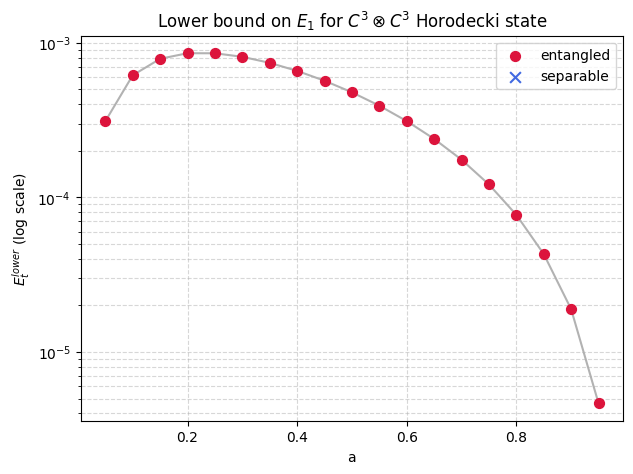

In [ ]:
horodecki_res = get_SDP_bounds(
    m=3,
    generator=C3C3_horodecki,
    label="C3C3_horodecki",
    param_range=(0.05, 1.0, 0.05),
)
plot_Etl_bounds(horodecki_res, 'Lower bound on $E_1$ for $C^3 \\otimes C^3$ Horodecki state', xlabel='a')


## CrossHatch + max mix

[get_SDP_bounds] loading complete cached results from sdp_results/cross_hatch_maxmixed_m3_k2_0.0_1.0_0.05.json


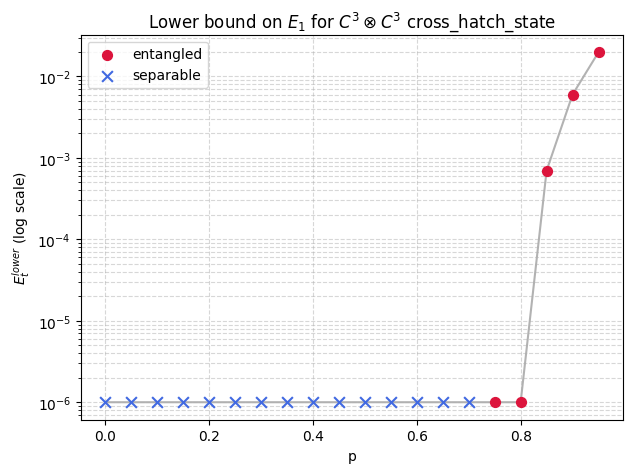

In [ ]:
crosshatch_gen = convex_combination_generator(cross_hatch_state(), max_mixed(9))
crosshatch_res = get_SDP_bounds(
    m=3,
    generator=crosshatch_gen,
    label="cross_hatch_maxmixed",
    param_range=(0.0, 1.0, 0.05),
)
plot_Etl_bounds(crosshatch_res, 'Lower bound on $E_1$ for $C^3 \\otimes C^3$ cross_hatch_state')


UPB

[get_SDP_bounds] loading complete cached results from sdp_results/UPB_maxmixed_m3_k2_0.0_1.0_0.05.json


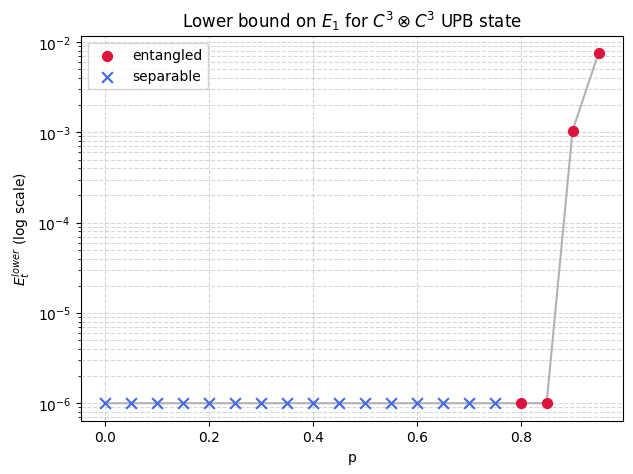

In [ ]:
upb_gen = convex_combination_generator(UPB(), max_mixed(9))
upb_res = get_SDP_bounds(
    m=3,
    generator=upb_gen,
    label="UPB_maxmixed",
    param_range=(0.0, 1.0, 0.05),
)
plot_Etl_bounds(upb_res, 'Lower bound on $E_1$ for $C^3 \\otimes C^3$ UPB state')


## Chessboard

[get_SDP_bounds] loading complete cached results from sdp_results/chessboard_maxmixed_m3_k2_0.0_1.0_0.05.json


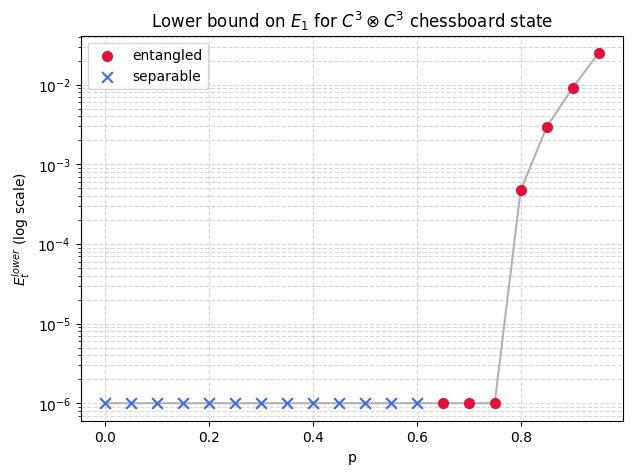

In [ ]:
chessboard_gen = convex_combination_generator(extremal_PPT_chessboard(), max_mixed(9))
chessboard_res = get_SDP_bounds(
    m=3,
    generator=chessboard_gen,
    label="chessboard_maxmixed",
    param_range=(0.0, 1.0, 0.05),
)
plot_Etl_bounds(chessboard_res, 'Lower bound on $E_1$ for $C^3 \\otimes C^3$ chessboard state')


# Entangled mixed state in $\mathbb{C}^3 \otimes \mathbb{C}^4$

In [ ]:
# from CmCn_entangled.random_PPT import CmCn_random_mixed_entangled_state

# nb_identified = 0
# for _ in range(5):
#     state = CmCn_random_mixed_entangled_state(3,4)
#     obj, omega_sym = SDP(antiSymProjector(2), state, 3,4)
#     if obj > SDP_TOL:
#         nb_identified += 1
# print(f"identified {nb_identified}")

# Entangled mixed state in $\mathbb{C}^4 \otimes \mathbb{C}^4$

In [ ]:
# from toqito.states import breuer
# m=4
# state = breuer(4, 0.1)
# obj, omega_sym = SDP(antiSymProjector(2), state, m,m)
# print(f"{obj}, {obj > SDP_TOL} expect true")

In [ ]:
# nb_identified = 0
# for _ in range(3):
#     state = CmCn_random_mixed_entangled_state(4,4)
#     obj, omega_sym = SDP(antiSymProjector(2), state, 4,4)
#     if obj > SDP_TOL:
#         nb_identified += 1
# print(f"identified {nb_identified}")

## Pianni

In [ ]:
from C4C4_PPT_entangled.piani_state import pianni

pianni_gen = convex_combination_generator(pianni(), max_mixed(4**2))
pianni_res = get_SDP_bounds(
    m=4,
    generator=pianni_gen,
    label="pianni_maxmixed",
    param_range=(0.0, 1.0, 0.05),           
)
plot_Etl_bounds(pianni_res, 'Lower bound on $E_1$ for $C^4 \\otimes C^4$ Pianni state')


pianni_maxmixed:   0%|          | 0/20 [00:00<?, ?it/s]

0.0
obj True
0.05
obj True
0.1
obj True
0.15000000000000002
obj True
0.2
obj True
0.25
obj True
0.30000000000000004
obj True
0.35000000000000003
obj True
0.4
obj True
0.45
obj True
0.5
obj True
0.55
obj True
0.6000000000000001
obj True
0.65


KeyboardInterrupt: 

Grid, edge, chessboard, extreme PPT

Pyramid tiles


# Graph

In [ ]:
all_results = {
    "Horodecki": horodecki_res,
    "CrossHatch + max mixed": crosshatch_res,
    "UPB + max mixed": upb_res,
    "Chessboard + max mixed": chessboard_res,
    "Pianni + max mixed": pianni_res,
}

colors = plt.cm.tab10.colors # type: ignore

plt.figure(figsize=(9, 6))

for i, (name, res) in enumerate(all_results.items()):
    color = colors[i % len(colors)]

    p_vals = res["p_vals"]
    Etl_vals = res["Etl_vals"]
    separable = res["separable"]

    entangled_mask = ~separable
    if not np.any(entangled_mask):
        continue  # nothing entangled found for this state, skip

    p_ent = p_vals[entangled_mask]
    Etl_ent = Etl_vals[entangled_mask]

    # sort by p in case the entangled points aren't already ordered
    order = np.argsort(p_ent)
    p_ent = p_ent[order]
    Etl_ent = Etl_ent[order]

    plt.plot(p_ent, Etl_ent, color=color, marker="o", markersize=4,
              linewidth=1.5, label=name)

    if name != "Horodecki":
        p_start = p_ent.min()
        plt.axvline(p_start, color=color, linestyle=":", linewidth=1.5,
                     label=f"{name} onset (p={p_start:.2f})")

plt.yscale("log")
plt.xlabel("p")
plt.ylabel("$E_t^{lower}$ (log scale)")
plt.title("Lower bound on $E_1$ — entangled region only, all states")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend(fontsize=8, loc="best")
plt.show()